<h2>Load libraries</h2>

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
# Set theme
sns.set_theme(
    style="whitegrid",
    palette="Set2",
    rc={
        "figure.figsize": (12, 6)
    }
)
%matplotlib inline

In [33]:
# plot roc curve
def plot_roc_curve(true_y, y_prob):
    """
    plots the roc curve based of the probabilities
    """

    fpr, tpr, thresholds = roc_curve(true_y, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

<h2>Load dataset</h2>

In [34]:
# import csv file
df = pd.read_csv('spam.csv')

<h2>Background</h2>

The dataset was provided by Abdallah Wagih Ibrahim for Kaggle. It is under license Apache 2.0, more details are included in the file LICENSE.txt.

This dataset contains a collection of emails, categorized into two classes: "Spam" and "Non-Spam" (often referred to as "Ham"). These emails have been carefully curated and labeled to aid in the development of spam email detection models. Whether you are interested in email filtering, natural language processing, or machine learning, this dataset can serve as a valuable resource for training and evaluation.

<h2>Executive summary</h2>

Three models were used to classify emails as spam or non-spam: Multinomial Naive Bayes, Bernoulli Naive Bayes, and an RNN (Recurrent Neural Network) model.

<h2>Missing values</h2>

In [35]:
# check null values
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [36]:
# check na values
df.isna().sum()

Category    0
Message     0
dtype: int64

There are no any missing values in Category and Message features.

In [37]:
# check whether any messages are 'None'
(df['Message'] == 'None').sum()

np.int64(0)

None of the emails contain the text "None".

<h2>Exploratory Data Analysis</h2>

In [38]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [39]:
# check basic descriptive summary
df.describe()

,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


The dataframe contains 5,572 email records. The most common email message is "Sorry, I'll call later", which appears 30 times in the dataset. The ham category, which represents non-spam emails, contains 4,825 records.

The imbalance of classes is shown below:

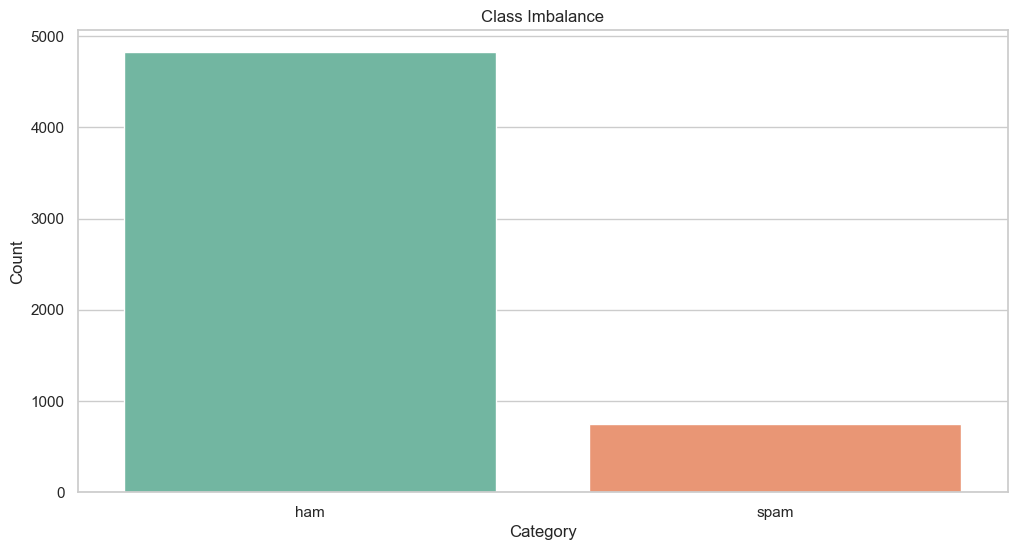

In [40]:
# bar chart of category feature
class_counts = df.Category.value_counts()
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x = class_counts.index,
           y = class_counts.values,
            hue = class_counts.index,
           ax = ax)
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.set_title('Class Imbalance')
plt.show();

The dataset is highly imbalanced. Almost 5000 records are categorised as non-spam, and less than 1000 are spam emails.

In [41]:
# calculate the percentage of class_counts
class_perc = df.Category.value_counts() / df.shape[0] * 100
class_perc

Category
ham     86.593683
spam    13.406317
Name: count, dtype: float64

The dataset contains 86.59% of 'ham' emails, and 13.41% of spam emails.

In [42]:
# check the distribution of text
df['Length'] = df['Message'].apply(len)
df.head()

,Category,Message,Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


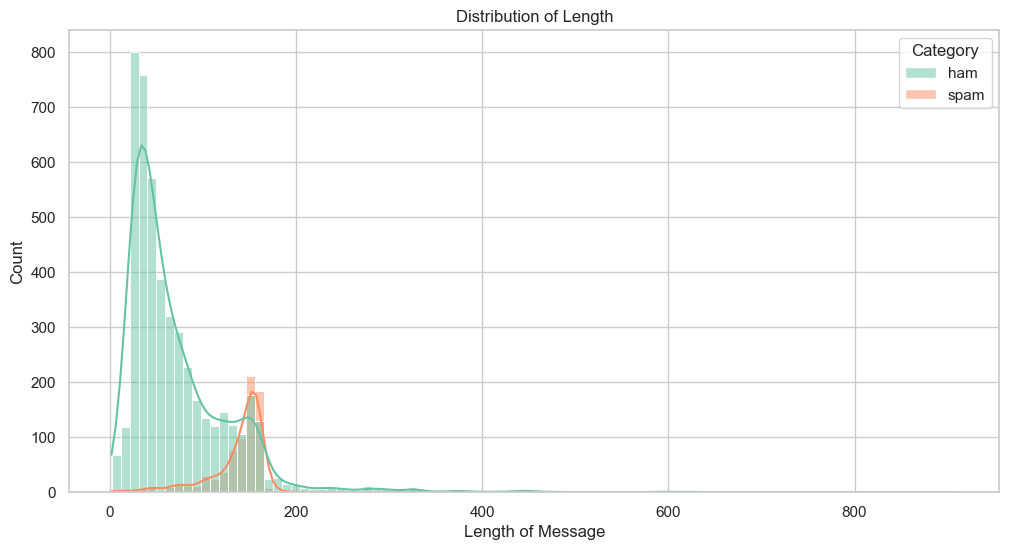

In [43]:
# plot a histogram of lenght
fig, ax = plt.subplots()
sns.histplot(data = df, x = "Length", hue = 'Category', kde = True)
ax.set_xlabel('Length of Message')
ax.set_ylabel('Count')
ax.set_title('Distribution of Length')
plt.show();

Most non-spam emails are fewer than 100 characters long, with the highest frequency occurring between 0 and 100 characters. There are also some messages that exceed 200 characters. In contrast, most spam emails are between 100 and 200 characters long, with the highest frequency occurring at around 160 characters.

<h2>Data processing</h2>

The Category feature is a binary variable with two values: ham and spam, which are encoded as 0 and 1. The labels are converted into numerical format to make them suitable for model training.

In [44]:
# convert labels into numerical format 0, 1
df.loc[:, 'Category'] = df.Category.map({'ham': 0, 'spam': 1})
df['Category'] = df['Category'].astype(int)
df.head()

,Category,Message,Length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


The train_df was split into a training and test dataset. After splitting, the training set contains 80% of the data, while the test set contains 20%.

In [45]:
# train & test split
X = df['Message']
x_train, x_test, y_train, y_test = train_test_split(X, df['Category'], test_size=0.20, random_state=100, stratify=df['Category'])

<h3>Bag of Words</h3>

CountVectorizer from sklearn library was used to convert raw text into a numerical matrix based on the frequency of each word. This process is needed for Naive Bayes models.

In [15]:
# create bag of words

vectorizer = CountVectorizer()
x_train_nb = vectorizer.fit_transform(x_train)
x_test_nb = vectorizer.transform(x_test)

<h2>Naive Bayes</h2>

Two Naive Bayes models were used: Multinomial Naive Bayes, which uses word frequencies as features, and Bernoulli Naive Bayes, which uses binary features indicating whether a word is present or absent in a document.

<h3>Multinomial Naive Bayes</h3>

<h4>Training model</h4>

In [16]:
%%time

# create model
mnb_model = MultinomialNB()

# fit model
mnb_model.fit(x_train_nb, y_train)

# predict
predict_mnb = mnb_model.predict(x_test_nb)

CPU times: total: 0 ns
Wall time: 4.27 ms


In [17]:
# predict probability
mnb_prob_predict = mnb_model.predict_proba(x_test_nb)[:, 1]

In [18]:
# print confusion matrix
print(confusion_matrix(y_test, predict_mnb))
print(classification_report(y_test, predict_mnb))
print(roc_auc_score(y_test, mnb_prob_predict))

[[959   7]
 [ 10 139]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.95      0.93      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115

0.9847082690677671


Logistic Regression AUC score: 0.9847082690677671


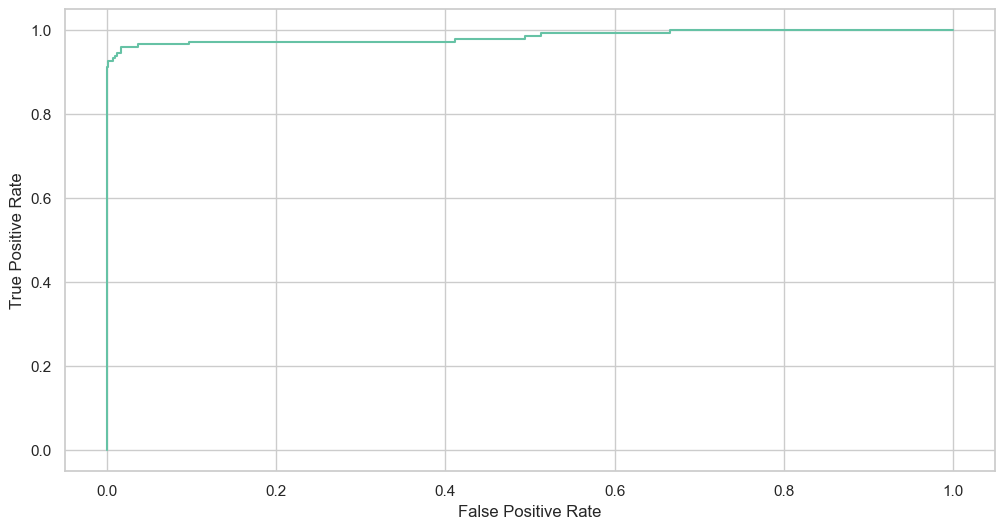

In [19]:
# plot ROC AUC
plot_roc_curve(y_test, mnb_prob_predict)
print(f'Multinomial Naive Bayes AUC score: {roc_auc_score(y_test, mnb_prob_predict)}')
plt.show();

The model achieved a ROC-AUC of 0.98, indicating strong overall discriminative ability between the two classes. For the “ham” (class 0) category, precision is 0.99, while for the “spam” (class 1) category it is 0.95. This indicates almost no false alarms for ham and a small number of false positives for spam. The recall for ham is 0.99, meaning almost all ham messages were correctly identified. For spam, recall is 0.93, indicating that a small number of spam messages were missed.

<h3>Bernoulli Naive Bayes</h3>

<h4>Training model</h4>

In [22]:
%%time

# create model
bnb_model = BernoulliNB()

# fit model
bnb_model.fit(x_train_nb, y_train)

# predict
predict_bnb = bnb_model.predict(x_test_nb)

CPU times: total: 0 ns
Wall time: 2.46 ms


In [23]:
# predict probability
bnb_prob_predict = bnb_model.predict_proba(x_test_nb)[:, 1]

In [24]:
# print confusion matrix
print(confusion_matrix(y_test, predict_bnb))
print(classification_report(y_test, predict_bnb))
print(roc_auc_score(y_test, bnb_prob_predict))

[[964   2]
 [ 19 130]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.98      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

0.9970681006572456


Bernoulli Naive Bayes AUC score: 0.9970681006572456


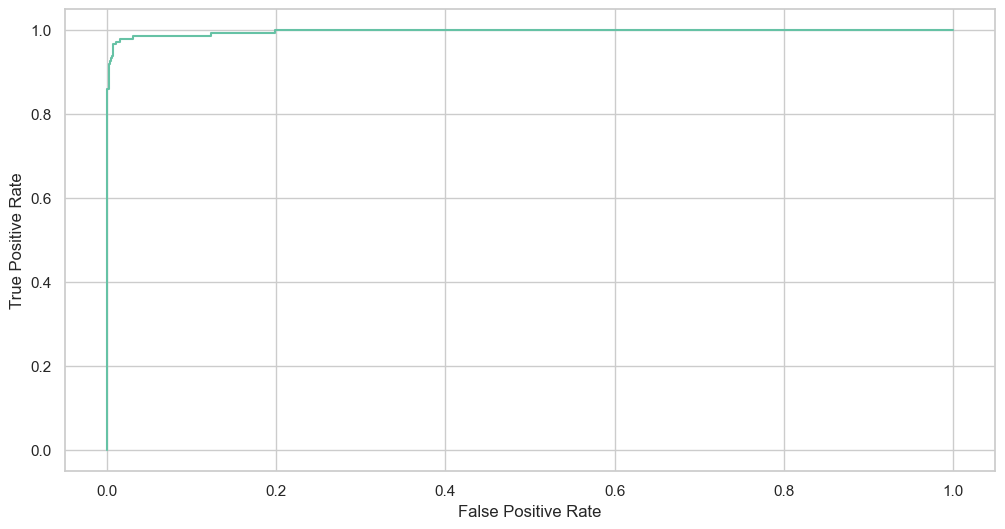

In [25]:
# plot ROC AUC
plot_roc_curve(y_test, bnb_prob_predict)
print(f'Bernoulli Naive Bayes AUC score: {roc_auc_score(y_test, bnb_prob_predict)}')
plt.show();

The model achieved a ROC-AUC of 0.997, indicating strong overall discriminative ability between the two classes. For both classes the precision is 0.98. The recall for ham is 1.00, meaning that all ham messages were correctly identified. For spam, recall is 0.87, indicating that a larger number of spam messages were missed comparing to the Multinomial Naive Bayes model. 

<h3>RNN - Recurrent Neural Network model</h3>

<h4>Tokenizing</h4>

The tokenizer creates the exact numerical sequence that allows the RNN to process and "remember" the order of words.

In [46]:
# Encode labels
label_encoder = LabelEncoder()

y_train_rnn = label_encoder.fit_transform(y_train)
y_test_rnn = label_encoder.transform(y_test)

# Fit tokenizer ONLY on training data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(x_train)

# Convert text to sequences
x_train_rnn = tokenizer.texts_to_sequences(x_train)
x_test_rnn = tokenizer.texts_to_sequences(x_test)

# Determine maximum sequence length from training data
max_sequence_length = max(len(seq) for seq in x_train_rnn)

# Pad sequences
x_train_rnn = pad_sequences(x_train_rnn, maxlen=max_sequence_length)
x_test_rnn = pad_sequences(x_test_rnn, maxlen=max_sequence_length)

<h4>Create model</h4>

An embedding dimension of 100 was selected to provide a rich vector representation of words while allowing the model to learn semantic relationships between them.
The model consists of three main layers. First, an Embedding layer converts each word index into a dense vector representation, allowing the model to learn semantic relationships between words. Next, a SimpleRNN layer with 128 units processes the sequence of word embeddings and captures patterns across the text by maintaining information from previous time steps. Finally, a Dense output layer with a sigmoid activation produces a probability score for binary classification (e.g., spam or ham).

In [53]:
# create simple RNN model
embedding_dim = 100
vocab_size = len(tokenizer.word_index) + 1

rnn_model = Sequential([
    Embedding(vocab_size, embedding_dim),
    SimpleRNN(128),
    Dropout(0.3),
    Dense(1, activation = 'sigmoid')
])

<h4>Training model</h4>

In [54]:
# compile model
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [55]:
# fit model
rnn_model.fit(x_train_rnn, y_train_rnn, epochs=15, batch_size=64, validation_data=(x_test_rnn, y_test_rnn))

Epoch 1/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.8943 - loss: 0.2873 - val_accuracy: 0.9668 - val_loss: 0.1216
Epoch 2/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9852 - loss: 0.0546 - val_accuracy: 0.9848 - val_loss: 0.0641
Epoch 3/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9955 - loss: 0.0210 - val_accuracy: 0.9874 - val_loss: 0.0580
Epoch 4/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9672 - loss: 0.0903 - val_accuracy: 0.9534 - val_loss: 0.1387
Epoch 5/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9881 - loss: 0.0398 - val_accuracy: 0.9839 - val_loss: 0.0619
Epoch 6/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9966 - loss: 0.0137 - val_accuracy: 0.9857 - val_loss: 0.0620
Epoch 7/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9982 - loss: 0.0082 - val_accuracy: 0.9857 - val_loss: 0.0634
Epoch 8/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9987 - loss: 0.0065 - val_accuracy: 0.9857 - v

<h4>Evaluate model</h4>

In [56]:
rnn_model.evaluate(x_test_rnn, y_test_rnn)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9857 - loss: 0.0706


[0.07063305377960205, 0.9856502413749695]

<h4>Predict</h4>

In [59]:
y_prob_rnn = rnn_model.predict(x_test_rnn)
y_pred_rnn = (y_prob_rnn > 0.5).astype(int)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [61]:
# print confusion matrix
print(confusion_matrix(y_test_rnn, y_pred_rnn))
print(classification_report(y_test_rnn, y_pred_rnn))
print(roc_auc_score(y_test_rnn, y_prob_rnn))

[[963   3]
 [ 13 136]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.98      0.91      0.94       149

    accuracy                           0.99      1115
   macro avg       0.98      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115

0.9919060124779412


Random Forest Classifier AUC score: 0.9548230438951187


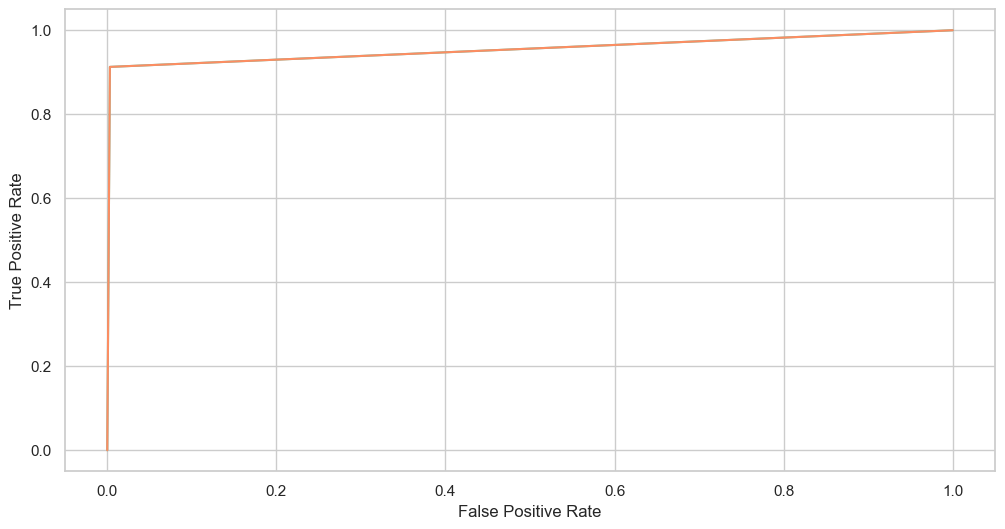

In [63]:
# plot ROC AUC
plot_roc_curve(y_test, y_pred_rnn)
print(f'Random Forest Classifier AUC score: {roc_auc_score(y_test, y_pred_rnn)}')
plt.show()

The RNN model achieved a ROC-AUC score of 0.992, indicating excellent overall discriminative performance. For the “ham” (class 0) category, precision was 0.99 and recall was 1.00, meaning almost all legitimate messages were correctly identified with virtually no false alarms. For the “spam” (class 1) category, precision was 0.98 and recall was 0.91, indicating that most spam messages were correctly detected, although a small number were missed. Overall, the model achieved 99% accuracy and a weighted F1-score of 0.99, demonstrating strong performance across both classes.

<h2>Summary</h2>

<b>This system can be used in a real-world email/SMS filtering pipeline where messages are automatically classified as spam or legitimate (ham) before reaching users.</b>

<h5>Multinomial Naive Bayes (balanced baseline model)</h5>

This model provides a strong balance between precision and recall. With high recall for spam (0.93), it correctly identifies most unwanted messages while maintaining a low false-positive rate for legitimate messages. In business terms, this reduces the risk of blocking important customer messages, while still filtering the majority of spam.

<h5>Bernoulli Naive Bayes (high strictness model)</h5>

This model achieves very high recall for ham (1.00) but lower recall for spam (0.87). This means it prioritises avoiding disruption to users (no legitimate messages blocked), but allows more spam to pass through. In a business context, this is suitable for environments where false positives are more costly than false negatives, such as banking or customer support communication.

<h5>RNN model (best overall performance model)</h5>

The RNN achieves the strongest overall performance with 99% accuracy and ROC-AUC of 0.992. It provides very high precision for spam (0.98) and strong recall (0.91), meaning it is effective at reducing spam exposure while keeping false alarms low. In business terms, this model offers the best trade-off between user experience and spam protection, making it suitable for production deployment.

<h5>Business impact summary</h5>
Reduced spam exposure - improves user experience and platform trust
Low false positives (ham incorrectly flagged as spam) → avoids blocking important messages, preventing potential revenue loss or customer dissatisfaction
High recall for spam - reduces phishing and fraud risk
Automated filtering system → reduces manual moderation costs